In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
import random
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [9]:

df = pd.read_csv("Student_Performance.csv")
df = pd.get_dummies(df, columns=["Extracurricular Activities"], dtype=int)
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]
scaler = StandardScaler()


X_train, X_test, y_train, y_test =  train_test_split( X, y, test_size=0.3)
df.head()




,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
0,7,99,9,1,91.0,0,1
1,4,82,4,2,65.0,1,0
2,8,51,7,2,45.0,0,1
3,5,52,5,2,36.0,0,1
4,7,75,8,5,66.0,1,0


plan what to do:
1) to split dataset to batches
2) count loss of this weigths on particular batch
3) get deriv from loss by w calculate gradient for weights
4) update weights by gradient + L2 regulizator


In [10]:
class MultipleRegression():
    def __init__(self, lr, lm=0, epoch=30, batch_size=30):
        self.lr = lr
        self.epoch = epoch
        self.lm = lm
        self.batch_size = batch_size
        self.weights = None 
        self.bias = None
        self.scaler = StandardScaler()
        self.loss_history = []

    def _scale_train(self, data):
        return self.scaler.fit_transform(data)

    def _scale_predict(self, data):
        return self.scaler.transform(data)

    def _prepare_data(self, x, y):
        rng = np.random.default_rng(seed=42)  # seed для воспроизводимости
        permutation = rng.permutation(x.shape[0])
        x_shuffled = x[permutation]
        y_shuffled = y[permutation]

        return x_shuffled, y_shuffled

    def _func(self, x):
        return x @ self.weights + self.bias

    def _loss(self, y, y_hat):
        e = y_hat - y
        mse = np.mean(e ** 2)
        mse += (self.lm / 2) * np.sum(self.weights ** 2)
        return mse

    def _grad_bias(self, n, pred, y):
        return 2/n*np.sum(pred-y)

    def _grad_weight(self, n, pred, y, x):
        return 2/n*x.T@(pred-y) + self.lm * self.weights

        


    def _backward(self, x, y, pred):
        grad_w = self._grad_weight(y.shape[0], pred,y,x)
        grad_b = self._grad_bias(y.shape[0], pred,y)


        self.weights -= self.lr*grad_w
        self.bias -=self.lr*grad_b

    def fit(self, x, y):
        x = np.asarray(x)
        y = np.asarray(y).ravel()
        n_samples, n_features = x.shape
        self.weights = np.zeros(shape=n_features)
        self.bias = 0
        x = self._scale_train(x)

        for _ in range(self.epoch):
            x,y = self._prepare_data(x,y)
            total_loss =0
            for batch_num in range(n_samples//self.batch_size):
                x_batch = x[batch_num*self.batch_size : batch_num*self.batch_size + self.batch_size]
                y_batch = y[batch_num*self.batch_size : batch_num*self.batch_size + self.batch_size]

                #forward
                pred = self._func(x_batch)

                batch_loss = self._loss(y=y_batch, y_hat=pred)
                total_loss += batch_loss
                self._backward(x_batch, y_batch, pred)

            self.loss_history.append(total_loss)



    def predict(self, x):
        x = np.asarray(x)
        x = self._scale_predict(x)
        pred = self._func(x)
        return pred
    


        

MSE  = 32.1070
RMSE = 5.6663
MAE  = 4.7152
R²   = 0.9120


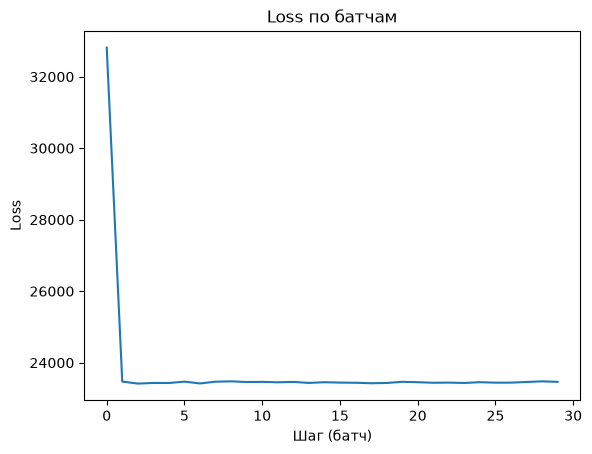

R² = 0.9888,  F = 103137.32,  p-value модели = 0.0000e+00

 признак       коэф    p-value
------------------------------
    bias   -22.5425     1.0000
      x0     2.8577     0.0000
      x1     1.0177     0.0000
      x2     0.4903     0.0000
      x3     0.1969     0.0000
      x4   -11.5776     1.0000
      x5   -10.9650     1.0000


(array([-22.54254956,   2.8577395 ,   1.01766695,   0.49026219,
          0.19687502, -11.57756477, -10.96498479]),
 array([0.99999158, 0.        , 0.        , 0.        , 0.        ,
        0.99999567, 0.9999959 ]),
 np.float64(0.0))

In [14]:
model = MultipleRegression(0.1, 0.7)

model.fit(X_train, y_train)

pred = model.predict(X_test)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot
def evaluate(y_true, y_pred, verbose=True):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    m = mse(y_true, y_pred)
    r = rmse(y_true, y_pred)
    a = mae(y_true, y_pred)
    r2_ = r2(y_true, y_pred)
    if verbose:
        print(f"MSE  = {m:.4f}")
        print(f"RMSE = {r:.4f}")
        print(f"MAE  = {a:.4f}")
        print(f"R²   = {r2_:.4f}")
    return {"mse": m, "rmse": r, "mae": a, "r2": r2_}



evaluate(y_test, pred)

plt.plot(model.loss_history)
plt.xlabel("Шаг (батч)")
plt.ylabel("Loss")
plt.title("Loss по батчам")
plt.show()

import numpy as np #тут уже ии чисто код просто чтобы проверить p value можели
from scipy import stats

def regression_pvalues(X, y):
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    n, d = X.shape

    Xb = np.hstack([np.ones((n, 1)), X])           # столбец единиц для bias
    w = np.linalg.lstsq(Xb, y, rcond=None)[0]      # OLS-коэффициенты

    residuals = y - Xb @ w
    sigma2 = np.sum(residuals ** 2) / (n - d - 1)  # остаточная дисперсия

    cov = sigma2 * np.linalg.inv(Xb.T @ Xb)
    se = np.sqrt(np.diag(cov))

    t_stats = w / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - d - 1))

    # F-test для всей модели
    y_mean = y.mean()
    ss_tot = np.sum((y - y_mean) ** 2)
    ss_res = np.sum(residuals ** 2)
    r2 = 1 - ss_res / ss_tot
    F = (r2 / d) / ((1 - r2) / (n - d - 1))
    p_model = 1 - stats.f.cdf(F, dfn=d, dfd=n - d - 1)

    # вывод
    print(f"R² = {r2:.4f},  F = {F:.2f},  p-value модели = {p_model:.4e}")
    print()
    print(f"{'признак':>8} {'коэф':>10} {'p-value':>10}")
    print("-" * 30)
    names = ["bias"] + [f"x{i}" for i in range(d)]
    for name, coef, p in zip(names, w, p_values):
        print(f"{name:>8} {coef:>10.4f} {p:>10.4f}")

    return w, p_values, p_model

regression_pvalues(X_train, y_train)